# 06 — Process and Journey

> **"A snapshot tells you where you are. A journey tells you how you got there."**

---

Phần lớn chart chỉ hiển thị **trạng thái cuối** — doanh thu tháng này, profit margin hiện tại.
Nhưng người ra quyết định thường cần hiểu **quá trình**:
- Revenue $10M đến từ đâu? (+$3M từ new customers, -$1M từ churn, +$2M từ upsell?)
- GDP 6.5% được tạo thành từ những thành phần nào?
- Series này có thể tách thành trend + seasonal + noise không?

**Process Visualization** là kỹ thuật hiển thị **hành trình từ A đến B**, không chỉ điểm B.

### Nội dung notebook này:

1. **Waterfall Chart** — Từ điểm xuất phát đến điểm kết thúc qua các bước
2. **Waterfall Variants** — Revenue bridge, P&L bridge, budget variance
3. **Contribution Chart** — Mỗi category đóng góp bao nhiêu % vào tổng
4. **Stacked Contribution** — Contribution theo thời gian (stacked area)
5. **Time Series Decomposition** — Tách trend / seasonal / residual
6. **Decomposition Interpretation** — Đọc kết quả decomposition
7. **Full Process Dashboard** — Kết hợp tất cả trong một layout

## Setup

In [1]:
# ── Dependency check ─────────────────────────────────────────────────────
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    """Install pkg if not available."""
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               pkg, '-q'])
        print(f'{pkg} installed ✓')
    else:
        print(f'  ✓ {name}')

_ensure('statsmodels')
_ensure('scipy')
# ─────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use('Agg')
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid
from vizint.core.axes_utils import format_thousands, format_percent, set_tick_style
from vizint.process import (
    waterfall_chart,
    contribution_chart,
    stacked_contribution,
    decomposition_chart,
)
from vizint.annotation import add_note, add_caption, label_last_point
from vizint.context import add_reference_line
from vizint.styling import categorical_colors
from vizint.styling.typography import TITLE_SIZE, CAPTION_SIZE, ANNOTATION_SIZE

np.random.seed(2024)
print('Setup OK ✓')

  ✓ statsmodels
  ✓ scipy
Setup OK ✓


## Synthetic Data

Tạo 4 tập dữ liệu:
1. **Revenue bridge** — từ Q4 2023 đến Q4 2024 qua các drivers
2. **P&L waterfall** — từ Revenue xuống Net Income
3. **Contribution data** — 8 product categories
4. **Monthly time series** — 5 năm để decompose

In [2]:
# --- Dataset 1: Revenue Bridge (YoY) ---
revenue_bridge_labels = [
    'Q4 2023',
    'New Customers',
    'Upsell / Expansion',
    'Price Increase',
    'Churn',
    'Contraction',
    'FX Impact',
    'Q4 2024',
]
revenue_bridge_values = [
    8_500,   # Starting: Q4 2023 (total, shown as base)
    +1_800,  # New customers
    +950,    # Upsell
    +420,    # Price
    -680,    # Churn
    -310,    # Contraction
    -180,    # FX
    0,       # Ending: will be auto-computed as sum
]
# Compute ending value
ending = revenue_bridge_values[0] + sum(revenue_bridge_values[1:-1])
revenue_bridge_values[-1] = ending

# --- Dataset 2: P&L Waterfall ---
pl_labels = [
    'Revenue',
    'COGS',
    'Gross Profit',
    'R&D',
    'S&M',
    'G&A',
    'EBIT',
    'Interest',
    'Tax',
    'Net Income',
]
pl_values = [
    10_500,   # Revenue (total)
    -4_200,   # COGS
    0,        # Gross Profit (subtotal)
    -1_050,   # R&D
    -1_400,   # S&M
    -630,     # G&A
    0,        # EBIT (subtotal)
    -180,     # Interest
    -510,     # Tax
    0,        # Net Income (total)
]
# Compute subtotals
pl_values[2]  = pl_values[0]  + pl_values[1]               # Gross Profit
pl_values[6]  = pl_values[2]  + sum(pl_values[3:6])         # EBIT
pl_values[9]  = pl_values[6]  + pl_values[7] + pl_values[8] # Net Income
pl_total_idx  = [0, 2, 6, 9]   # indices treated as totals

# --- Dataset 3: Product Contribution ---
products_contrib = [
    'Enterprise', 'SMB', 'Consumer',
    'API / Dev', 'Marketplace', 'Professional Svcs',
    'Hardware', 'Other',
]
contrib_values = [38.5, 22.3, 14.8, 9.2, 6.7, 4.9, 2.4, 1.2]

# --- Dataset 4: Monthly time series (5 years) ---
# Dùng irregular trend + mixed harmonics + large noise
# để sau khi decompose residual vẫn có structure rõ ràng
n_months = 60
idx = pd.date_range('2020-01', periods=n_months, freq='ME')
t_arr = np.arange(n_months)

# Non-linear trend (piecewise)
trend_ts  = 800 + 10 * t_arr + 0.08 * t_arr**2
trend_ts[30:] += 80   # structural break ở tháng 30

# Mixed seasonality: annual + semi-annual harmonics
seasonal_ts = (
    110 * np.sin(2 * np.pi * t_arr / 12 - np.pi/2)
    + 40 * np.sin(2 * np.pi * t_arr / 6)
)

# Irregular noise: large enough to survive decomposition
np.random.seed(2024)
residual_ts = np.random.randn(n_months) * 55
# Inject a few large shocks
residual_ts[[8, 22, 45]] += np.array([140, -160, 130])

ts_values = trend_ts + seasonal_ts + residual_ts
ts_series = pd.Series(ts_values, index=idx)

# --- Dataset 5: Stacked contribution over time ---
T = 24
months_t = np.arange(T)
segment_series = {
    'Enterprise':  2500 + np.cumsum(np.random.randn(T) * 60  + 25),
    'SMB':         1800 + np.cumsum(np.random.randn(T) * 45  + 15),
    'Consumer':    1200 + np.cumsum(np.random.randn(T) * 35  + 8),
    'API / Dev':   600  + np.cumsum(np.random.randn(T) * 25  + 12),
}

print(f'Revenue bridge ending value : ${ending:,.0f}K')
print(f'P&L Net Income              : ${pl_values[9]:,.0f}K')
print(f'Top contributor             : {products_contrib[0]} ({contrib_values[0]:.1f}%)')
print(f'Time series length          : {n_months} months')

Revenue bridge ending value : $10,500K
P&L Net Income              : $2,530K
Top contributor             : Enterprise (38.5%)
Time series length          : 60 months


## 1. Waterfall Chart — Revenue Bridge

Waterfall chart (bridge chart) hiển thị hành trình từ giá trị đầu đến giá trị cuối
qua các bước tăng/giảm trung gian.

Người xem thấy ngay:

- tổng thay đổi là bao nhiêu
- driver nào đóng góp nhiều nhất (tích cực / tiêu cực)
- thứ tự tác động của từng factor

---

### Khi dùng Waterfall chart

Waterfall phù hợp khi phân tích:

- revenue YoY change
- profit breakdown
- cost components
- variance analysis
- budget vs actual

Giúp trả lời:

tăng bao nhiêu và do đâu.

---

### Cấu trúc Waterfall

Waterfall gồm:

- Start value
- Increment / Decrement steps
- End value

Biểu diễn:

Start → Δ1 → Δ2 → Δ3 → … → End

Trong đó mỗi bước:

- tăng → bar dương
- giảm → bar âm

---

### Revenue bridge

Revenue thay đổi:

Revenue 2024 = Revenue 2023 + Σ drivers

Các drivers ví dụ:

- price increase
- volume growth
- churn
- new customers
- discount

Waterfall cho thấy contribution của từng driver.

---

### Cách đọc Waterfall

Bar đầu:

giá trị ban đầu

Bars giữa:

các thay đổi cộng dồn

Bar cuối:

giá trị cuối

Mỗi bar bắt đầu từ:

previous cumulative value

---

### Ưu điểm

Waterfall giúp:

- hiểu change decomposition
- thấy contribution từng factor
- thấy thứ tự tác động
- tốt cho business storytelling

So với bar chart:

bar chart → chỉ thấy values
waterfall → thấy hành trình thay đổi

---

### Revenue YoY Bridge

Ví dụ:

Q4 2023 revenue
+ price increase
+ new customers
− churn
− discount
= Q4 2024 revenue

Waterfall hiển thị rõ từng bước.

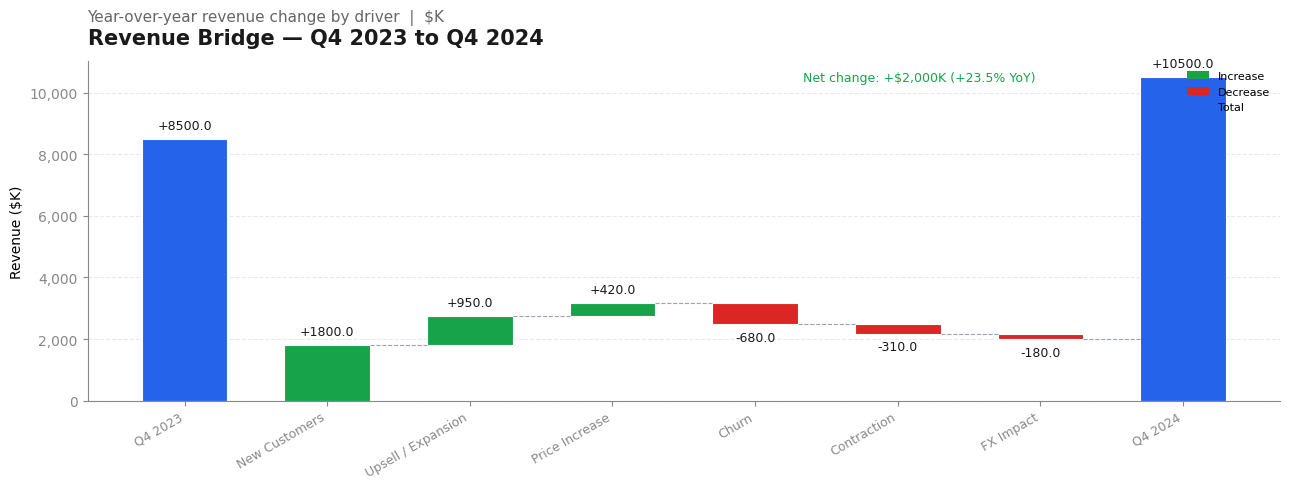

In [3]:
chart = (
    ChartBuilder(figsize=(13, 5))
    .set_title('Revenue Bridge — Q4 2023 to Q4 2024')
    .set_subtitle('Year-over-year revenue change by driver  |  $K')
    .build()
)
ax = chart.ax

waterfall_chart(
    ax,
    labels=revenue_bridge_labels,
    values=revenue_bridge_values,
    positive_color='#16A34A',
    negative_color='#DC2626',
    total_color='#2563EB',
    total_indices=[0, 7],      # first and last are totals
    bar_width=0.6,
    show_values=True,
    value_fontsize=9,
    connector_color='#9CA3AF',
)

format_thousands(ax, 'y')
ax.set_ylabel('Revenue ($K)')

# Net change annotation
net_change = ending - revenue_bridge_values[0]
pct_change = net_change / revenue_bridge_values[0] * 100
add_note(
    ax,
    f'Net change: +${net_change:,.0f}K (+{pct_change:.1f}% YoY)',
    x=0.60, y=0.97,
    color='#16A34A' if net_change >= 0 else '#DC2626',
    fontsize=9,
)

plt.tight_layout()
plt.show()

### Revenue YoY Bridge — How to Read

Waterfall chart hiển thị hành trình từ Q4 2023 đến Q4 2024 qua từng driver.

Start:

Q4 2023 = 8,500

Drivers tăng:

New Customers +1,800
Upsell / Expansion +950
Price Increase +420

Drivers giảm:

Churn −680
Contraction −310
FX Impact −180

End:

Q4 2024 = 10,500

---

### Net change

Tổng thay đổi:

Net change = sum(increases) − sum(decreases)

= 1,800 + 950 + 420 − 680 − 310 − 180
= +2,000

YoY growth:

+23.5%

---

### Contribution breakdown

Drivers tích cực lớn nhất:

New Customers → driver chính
Upsell / Expansion → secondary growth
Price Increase → minor uplift

Drivers tiêu cực:

Churn → giảm lớn nhất
Contraction → giảm nhẹ
FX Impact → nhỏ nhất

---

### Cumulative logic

Waterfall hoạt động theo cumulative sum:

8,500
+ 1,800 → 10,300
+ 950 → 11,250
+ 420 → 11,670
− 680 → 10,990
− 310 → 10,680
− 180 → 10,500

---

### Insight

Revenue tăng chủ yếu do:

- acquisition mạnh
- expansion revenue
- price uplift

Nhưng bị kéo xuống bởi:

- churn
- contraction
- FX headwind

Growth vẫn dương mạnh.

---

### Khi dùng Revenue Bridge

Waterfall đặc biệt hữu ích cho:

- YoY revenue change
- variance analysis
- budget vs actual
- driver decomposition

Giúp trả lời:

Revenue tăng +2,000 là do đâu.

## 2. Waterfall Variants — P&L Bridge

Waterfall có nhiều ứng dụng:

- Revenue bridge — YoY driver analysis
- P&L bridge — từ Revenue xuống Net Income qua các cost line
- Budget variance — actual vs budget by category
- Cash flow — operating + investing + financing → ending cash

Khi có subtotals như Gross Profit hoặc EBIT, dùng total_indices để đánh dấu.
Các bar này được vẽ từ 0 thay vì từ running total.

---

### P&L Bridge Structure

P&L waterfall thường có dạng:

Revenue
− COGS
= Gross Profit

− Operating Expenses
= EBIT

− Interest
− Tax
= Net Income

Các subtotal:

- Gross Profit
- EBIT
- Net Income

được hiển thị như total bars.

---

### Running total logic

Các step bình thường:

value_i cộng dồn vào running total

Running total:

running_t = running_{t-1} + delta_t

Nhưng subtotal:

subtotal_k = running_t

Bar subtotal bắt đầu từ 0.

---

### Ví dụ P&L Bridge

Revenue = 10,000
COGS = −4,000
Gross Profit = 6,000

Opex = −2,500
EBIT = 3,500

Interest = −400
Tax = −900

Net Income = 2,200

Waterfall hiển thị rõ từng bước.

---

### Vì sao cần subtotal bars

Nếu không có subtotal:

khó thấy:

- Gross margin
- Operating margin
- Net margin

Subtotal giúp:

- chia block P&L
- đọc nhanh cấu trúc
- tăng readability

---

### total_indices

total_indices dùng để đánh dấu:

các bar là subtotal.

Các bar này:

- vẽ từ 0
- màu total
- không cộng thêm vào running

Giúp phân biệt:

delta bars vs total bars

---

### Khi dùng P&L waterfall

Dùng khi muốn:

- explain margin structure
- break down profit
- show cost impact
- show step-down profitability

Phổ biến trong:

- finance dashboard
- earnings report
- management deck

---

### Summary

Waterfall variants:

Revenue bridge → change drivers
P&L bridge → step-down profit
Budget variance → plan vs actual
Cash flow → movement of cash

Subtotal bars:

- vẽ từ 0
- dùng total_indices
- highlight intermediate totals

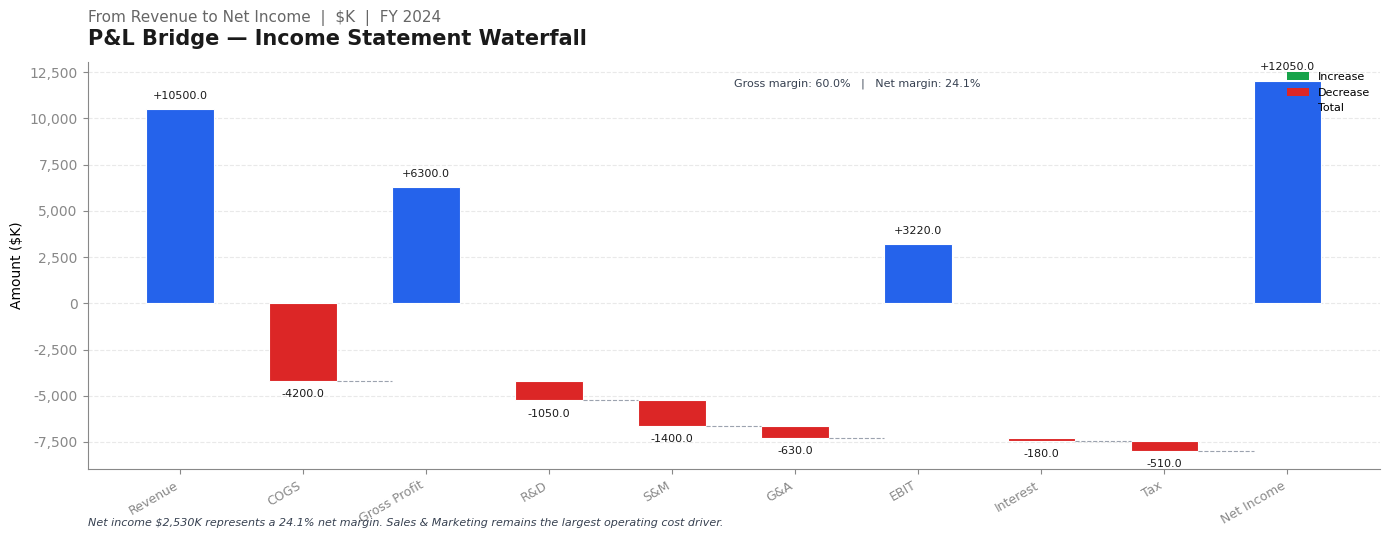

In [4]:
chart = (
    ChartBuilder(figsize=(14, 5.5))
    .set_title('P&L Bridge — Income Statement Waterfall')
    .set_subtitle('From Revenue to Net Income  |  $K  |  FY 2024')
    .build()
)
ax = chart.ax

waterfall_chart(
    ax,
    labels=pl_labels,
    values=pl_values,
    positive_color='#16A34A',
    negative_color='#DC2626',
    total_color='#2563EB',
    total_indices=pl_total_idx,
    bar_width=0.55,
    show_values=True,
    value_fontsize=8,
)

format_thousands(ax, 'y')
ax.set_ylabel('Amount ($K)')

# Net margin annotation
net_margin = pl_values[9] / pl_values[0] * 100
gross_margin = pl_values[2] / pl_values[0] * 100
add_note(
    ax,
    f'Gross margin: {gross_margin:.1f}%   |   Net margin: {net_margin:.1f}%',
    x=0.50, y=0.96,
    color='#374151', fontsize=8,
)

add_caption(
    ax,
    f'Net income ${pl_values[9]:,.0f}K represents a {net_margin:.1f}% net margin. '
    'Sales & Marketing remains the largest operating cost driver.',
    fontsize=CAPTION_SIZE,
)

plt.tight_layout()
plt.show()

## P&L Bridge — Visualization Notes

### Step-down profitability rõ ràng
Waterfall thể hiện trực tiếp dòng chảy:

Revenue → Gross Profit → EBIT → Net Income

Người xem đọc từ trái sang phải là hiểu cấu trúc P&L.

---

### Subtotal bars tạo checkpoints
Các bar tổng:

- Gross Profit
- EBIT
- Net Income

giúp chia P&L thành các block logic và dễ đọc margin structure.

---

### Phân biệt cost drivers
Các thanh giảm cho thấy đóng góp của từng cost:

- COGS là chi phí lớn nhất
- S&M là operating cost lớn nhất
- Tax là bước giảm cuối cùng trước Net Income

Giúp xác định cost driver chính ngay lập tức.

---

### Nhìn được margin structure
Biểu đồ cho phép đọc nhanh:

- Gross margin
- Operating margin
- Net margin

mà không cần tính toán thủ công.

---

### So với bar chart thông thường
Waterfall tốt hơn vì:

- thể hiện cumulative effect
- giữ được thứ tự accounting
- highlight intermediate totals
- kể câu chuyện "Revenue → Profit"

---

### Khi nên dùng visualization này

Dùng khi cần:

- explain profit structure
- show cost breakdown
- trình bày income statement
- management / finance dashboard

## 3. Waterfall — Budget Variance

**Variance waterfall** so sánh **Actual vs Budget** và hiển thị từng driver đóng góp
vào chênh lệch cuối cùng (total variance).

Biểu đồ trả lời trực tiếp:

- Vì sao vượt budget?
- Chi phí nào gây overspend?
- Khoản nào tiết kiệm bù lại?
- Net impact lên profit là bao nhiêu?

---

## Finance Sign Convention

Quy ước thường dùng trong finance:

**Revenue variance**

Actual > Budget → Favorable (xanh)
Actual < Budget → Unfavorable (đỏ)

**Cost variance**

Actual < Budget → Favorable (xanh)
Actual > Budget → Unfavorable (đỏ)

Lý do: cost thấp hơn budget là tốt.

---

## Structure của Variance Waterfall

Thông thường dạng:

Budget Profit
+ Revenue variance
− COGS variance
− Opex variance
+ Other variance
= Actual Profit

Hoặc dạng cost:

Budget Cost
+ Material variance
+ Labor variance
− Overhead saving
= Actual Cost

---

## Vì sao Waterfall phù hợp cho variance

Waterfall thể hiện:

- từng driver riêng biệt
- cumulative effect
- net impact cuối cùng
- favorable vs unfavorable rõ ràng

So với bar chart:

Bar chart → chỉ thấy magnitude
Waterfall → thấy **impact lên bottom line**

---

## Visual Encoding

Màu sắc:

- Xanh → favorable
- Đỏ → unfavorable
- Xám / xanh đậm → total (Budget / Actual)

Hướng bar:

- Lên → positive impact
- Xuống → negative impact

Giúp đọc ngay mà không cần số.

---

## Ví dụ Budget Variance

Budget profit = 5,000

Drivers:

Revenue variance = +400
COGS variance = −250
Opex variance = −300
FX gain = +150

Actual profit:

= 5,000 + 400 − 250 − 300 + 150
= 5,000

Biểu đồ cho thấy:

- revenue tăng bù cho cost overspend
- net variance = 0
- performance cân bằng

---

## Khi nên dùng Budget Variance Waterfall

Dùng khi cần:

- explain budget vs actual
- variance analysis
- cost control reporting
- monthly finance review
- management deck

---

## Visualization Benefits

- highlight variance drivers
- dễ phân biệt favorable/unfavorable
- thấy cumulative impact
- đọc nhanh root cause
- phù hợp storytelling finance

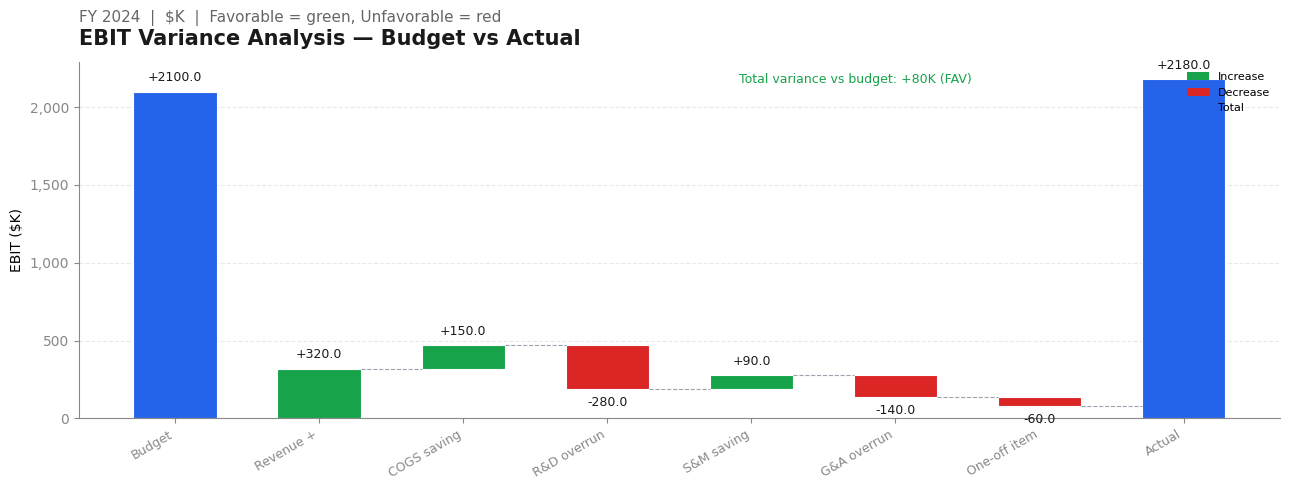

In [5]:
variance_labels = [
    'Budget',
    'Revenue +',
    'COGS saving',
    'R&D overrun',
    'S&M saving',
    'G&A overrun',
    'One-off item',
    'Actual',
]
variance_values = [
    2_100,   # Budget EBIT
    +320,    # Revenue beat
    +150,    # COGS below budget
    -280,    # R&D above budget
    +90,     # S&M below budget
    -140,    # G&A above budget
    -60,     # One-off restructuring
    0,       # Actual (computed)
]
variance_values[-1] = variance_values[0] + sum(variance_values[1:-1])

chart = (
    ChartBuilder(figsize=(13, 5))
    .set_title('EBIT Variance Analysis — Budget vs Actual')
    .set_subtitle('FY 2024  |  $K  |  Favorable = green, Unfavorable = red')
    .build()
)
ax = chart.ax

waterfall_chart(
    ax,
    labels=variance_labels,
    values=variance_values,
    positive_color='#16A34A',
    negative_color='#DC2626',
    total_color='#2563EB',
    total_indices=[0, 7],
    bar_width=0.58,
    show_values=True,
    value_fontsize=9,
)

format_thousands(ax, 'y')
ax.set_ylabel('EBIT ($K)')

net_var = variance_values[-1] - variance_values[0]
add_note(
    ax,
    f'Total variance vs budget: {"+" if net_var >= 0 else ""}{net_var:,.0f}K '
    f'({"FAV" if net_var >= 0 else "UNF"})',
    x=0.55, y=0.97,
    color='#16A34A' if net_var >= 0 else '#DC2626',
    fontsize=9,
)

plt.tight_layout()
plt.show()

## Budget Variance Waterfall — Visualization Notes

### Favorable vs Unfavorable bằng màu
Màu xanh / đỏ encode trực tiếp:

- xanh → favorable
- đỏ → unfavorable

Người xem nhận biết ngay variance tốt / xấu mà không cần đọc số.

---

### Bridge Budget → Actual rõ ràng
Waterfall thể hiện dòng chảy:

Budget → drivers → Actual

Giúp hiểu **variance hình thành như thế nào** thay vì chỉ thấy 2 cột.

---

### Driver-level decomposition
Mỗi variance được tách riêng:

- revenue
- COGS
- R&D
- S&M
- G&A

Giúp xác định **nguồn gốc variance** thay vì chỉ thấy tổng.

---

### Cumulative effect dễ đọc
Các bar nối tiếp nhau cho thấy:

variance cộng dồn theo thứ tự

Người xem thấy rõ:

drivers nào bù trừ cho nhau.

---

### Subtotal endpoints rõ ràng
Budget và Actual được vẽ như total bars:

- bắt đầu từ 0
- màu riêng
- đóng vai trò anchor

Giúp định vị toàn bộ variance.

---

### Phù hợp financial storytelling
Waterfall hỗ trợ:

- explain variance
- show drivers
- highlight overruns
- highlight savings

Tốt hơn bar chart vì thể hiện **impact lên bottom line**.

## 4. Contribution Chart — Share of Total

**Contribution chart** (horizontal bar) trả lời câu hỏi:
*"Category nào chiếm nhiều nhất trong tổng?"*

`contribution_chart` tự động:

- normalize về %
- sort giảm dần
- hiển thị ranking
- highlight top contributors

---

### 4.1 Horizontal layout tăng readability

Horizontal bar phù hợp khi:

- category labels dài
- nhiều nhóm cần hiển thị
- cần đọc text trực tiếp

So với vertical:

- không cần xoay label
- không bị chồng chữ
- đọc nhanh hơn

---

### 4.2 So sánh độ dài chính xác hơn

Mắt người so sánh **chiều dài ngang** tốt hơn chiều cao dọc:

- dễ thấy category lớn nhất
- dễ nhận biết chênh lệch nhỏ
- giảm perceptual error

Điều này làm ranking đáng tin cậy hơn.

---

### 4.3 Sorted order tạo ranking tự nhiên

Sort giảm dần giúp:

- top = quan trọng nhất
- bottom = long tail
- thứ tự rõ ràng

Người xem đọc từ trên xuống như bảng xếp hạng.

---

### 4.4 Share-of-total rõ ràng hơn absolute value

Normalize về % giúp:

- thấy tỷ trọng từng category
- so sánh dataset khác scale
- hiểu composition tổng

Tránh hiểu sai khi magnitude khác nhau.

---

### 4.5 Highlight concentration

Contribution chart làm rõ:

- top-heavy distribution
- Pareto pattern
- dominant categories
- long tail nhỏ

Phù hợp phân tích concentration.

---

### 4.6 Khi nên dùng

Dùng khi cần:

- share of total
- contribution analysis
- category ranking
- composition breakdown
- Pareto analysis

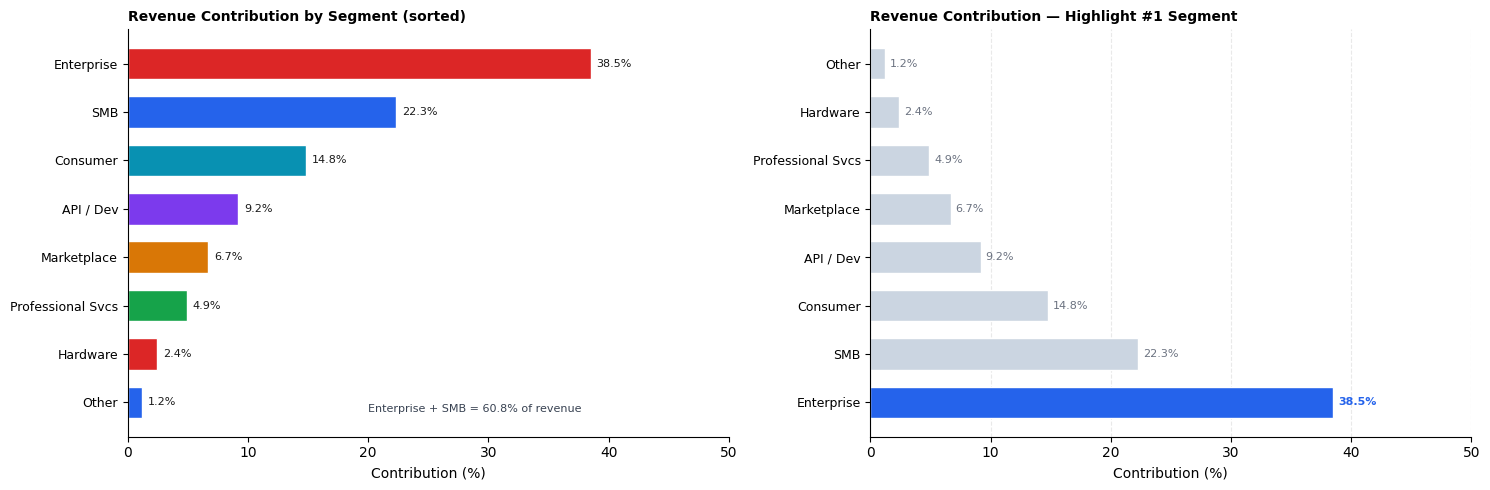

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Panel 1: Sorted (default)
ax = axes[0]
contribution_chart(
    ax,
    categories=products_contrib,
    contributions=contrib_values,
    palette='default',
    bar_height=0.65,
    show_values=True,
    value_fmt='{:.1f}%',
    sort=True,
)
ax.set_title('Revenue Contribution by Segment (sorted)',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlim(0, 50)
add_note(ax, 'Enterprise + SMB = 60.8% of revenue',
         x=0.40, y=0.08, color='#374151', fontsize=8)
despine(ax, left=False)

# Panel 2: Highlight top contributor
ax = axes[1]
cats_sorted = [x for _, x in sorted(
    zip(contrib_values, products_contrib), reverse=True
)]
vals_sorted = sorted(contrib_values, reverse=True)

bar_colors = ['#2563EB' if i == 0 else '#CBD5E1'
              for i in range(len(cats_sorted))]

y_pos = np.arange(len(cats_sorted))
ax.barh(y_pos, vals_sorted, height=0.65,
        color=bar_colors, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(cats_sorted, fontsize=9)

for i, v in enumerate(vals_sorted):
    ax.text(v + 0.4, i, f'{v:.1f}%',
            va='center', fontsize=8,
            color='#2563EB' if i == 0 else '#6B7280',
            fontweight='bold' if i == 0 else 'normal')

ax.set_xlabel('Contribution (%)')
ax.set_xlim(0, 50)
ax.set_title('Revenue Contribution — Highlight #1 Segment',
             loc='left', fontsize=10, fontweight='bold')
despine(ax, left=False); set_grid(ax, which='x')

plt.tight_layout()
plt.show()

## Contribution Chart — Visualization Notes

Biểu đồ sử dụng **horizontal contribution bars** để thể hiện tỷ trọng doanh thu theo segment,
giúp đọc nhanh cấu trúc phân bổ revenue.

### Sorted horizontal bars làm rõ ranking
Các segment được sắp xếp giảm dần:

- segment lớn nhất nằm trên cùng
- long tail nằm phía dưới
- ranking đọc từ trên xuống

Giúp xác định **top contributor** ngay lập tức.

### Normalize về % giúp so sánh trực tiếp
Trục x dùng contribution (%) thay vì revenue tuyệt đối:

- thấy tỷ trọng từng segment
- dễ so sánh giữa các nhóm
- không bị ảnh hưởng bởi scale

Biểu đồ trở thành **share-of-total view**.

### Highlight top segment tạo focus
Segment lớn nhất được tô màu nổi bật,
các segment còn lại được làm muted.

Cách này:

- thu hút attention vào leader
- giảm nhiễu thị giác
- làm rõ dominance của top segment

### Horizontal layout tăng readability
Category labels dài được hiển thị đầy đủ:

- không xoay chữ
- không chồng label
- dễ đọc nhiều segment

Phù hợp cho contribution analysis.

### Thể hiện concentration và long tail
Biểu đồ làm rõ:

- Enterprise chiếm tỷ trọng lớn nhất
- top 2 segment chi phối phần lớn revenue
- phần còn lại là long tail nhỏ

Giúp đánh giá mức độ **revenue concentration** nhanh chóng.

## 5. Stacked Contribution Over Time

**Stacked area chart** = contribution chart theo thời gian.
Cho thấy:

- Tổng tăng trưởng qua thời gian
- Mỗi segment chiếm bao nhiêu % của tổng tại mỗi thời điểm
- Segment nào đang tăng / giảm tỷ trọng

---

### 5.1 Composition và total trong một chart

Stacked area cho phép đọc đồng thời:

- tổng quy mô (đường biên trên)
- contribution từng segment
- thay đổi cơ cấu theo thời gian

Không cần tách thành multiple charts.

---

### 5.2 Đọc thay đổi tỷ trọng bằng độ dày band

Contribution được encode bằng **độ dày vùng**:

- band dày hơn → share tăng
- band mỏng hơn → share giảm
- band ổn định → share không đổi

Giúp phát hiện shift trong mix.

---

### 5.3 Nhận diện growth drivers

Khi tổng tăng:

- segment mở rộng nhanh → chiếm diện tích lớn hơn
- segment tăng chậm → bị thu hẹp tương đối

Cho thấy segment nào drive growth.

---

### 5.4 Continuous trend tốt cho time series

Area chart tạo hình liên tục:

- dễ thấy trend dài hạn
- dễ phát hiện regime change
- mượt hơn stacked bar

Phù hợp phân tích evolution theo thời gian.

---

### 5.5 Market share dynamics

Stacked contribution làm rõ:

- segment dominance thay đổi
- segment mới nổi lên
- segment suy giảm
- mix thay đổi theo thời gian

Phù hợp phân tích composition shift.

---

### 5.6 Hạn chế khi có nhiều segment

Stacked area khó đọc khi:

- quá nhiều category
- band mỏng khó phân biệt
- màu sắc gây nhiễu

Best practices:

- giới hạn 4–5 segment
- group phần nhỏ thành "Other"
- giữ thứ tự cố định
- dùng màu nhất quán

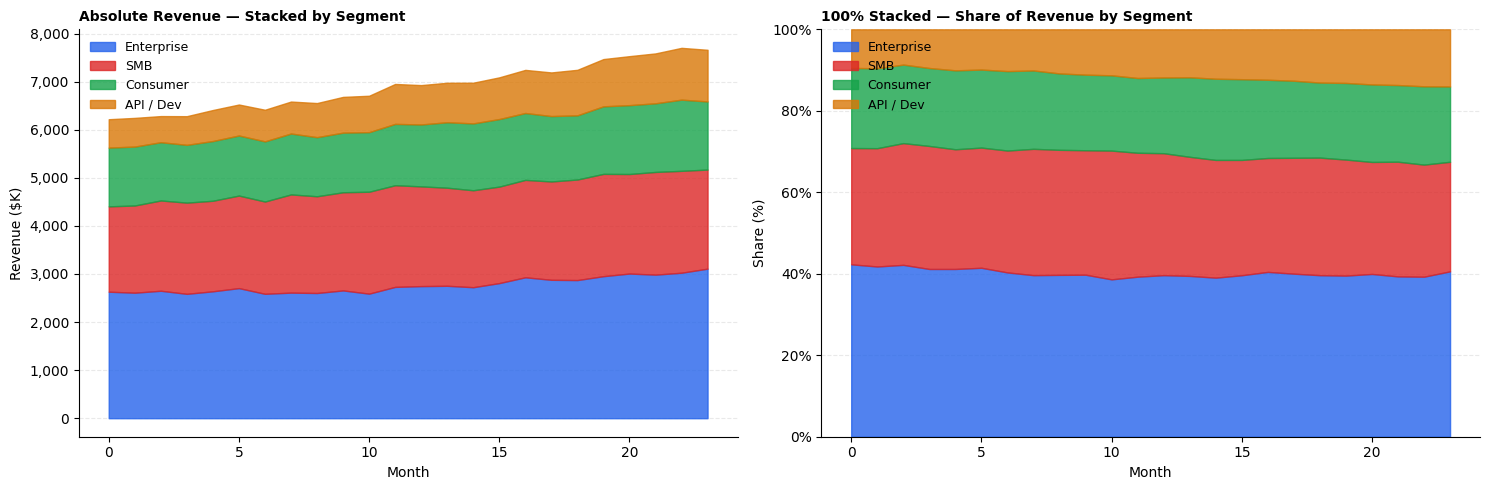

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Panel 1: Absolute stacked area
ax = axes[0]
stacked_contribution(
    ax,
    x=months_t,
    series=segment_series,
    palette='default',
    alpha=0.80,
    legend=True,
    legend_loc='upper left',
)
format_thousands(ax, 'y')
ax.set_title('Absolute Revenue — Stacked by Segment',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
despine(ax); set_grid(ax)

# Panel 2: 100% stacked (normalized)
ax = axes[1]
arrays = np.array(list(segment_series.values()))  # shape: (n_segments, T)
totals = arrays.sum(axis=0)  # shape: (T,)
normalized = {name: y / totals * 100
              for name, y in segment_series.items()}

stacked_contribution(
    ax,
    x=months_t,
    series=normalized,
    palette='default',
    alpha=0.80,
    legend=True,
    legend_loc='upper left',
)
ax.set_ylim(0, 100)
format_percent(ax, 'y', decimals=0)
ax.set_title('100% Stacked — Share of Revenue by Segment',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Share (%)')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

## Stacked Contribution Over Time — Visualization Notes

Biểu đồ đặt **stacked absolute** cạnh **100% stacked**, giúp tách biệt
**tăng trưởng tổng** và **thay đổi tỷ trọng**.

### Absolute stacked cho thấy total growth
Đường biên trên của stacked area thể hiện:

- tổng revenue tăng theo thời gian
- contribution tuyệt đối của từng segment
- segment nào đóng góp vào growth

Phù hợp để đọc scale expansion.

### 100% stacked tách riêng share dynamics
Chuẩn hóa về 100% giúp:

- loại bỏ ảnh hưởng tăng trưởng tổng
- chỉ còn lại thay đổi tỷ trọng
- dễ thấy segment gaining / losing share

Biểu đồ trở thành composition view.

### Hai chart bổ sung cho nhau
Absolute stacked trả lời:

- tổng có tăng không
- segment nào đóng góp growth

100% stacked trả lời:

- ai đang chiếm nhiều hơn
- mix đang thay đổi ra sao

Đặt cạnh nhau tránh hiểu sai khi chỉ dùng một chart.

### Band thickness encode contribution
Độ dày mỗi vùng biểu diễn:

- contribution tuyệt đối (chart trái)
- market share (chart phải)

Cho phép đọc trend mà không cần label nhiều.

### Giữ thứ tự stack ổn định
Các segment giữ thứ tự cố định theo thời gian:

- tránh band nhảy vị trí
- dễ theo dõi evolution
- giảm cognitive load

Quan trọng với stacked area.

### Phù hợp phân tích mix + growth
Visualization này tốt khi cần:

- theo dõi segment growth
- phân tích mix shift
- so sánh absolute vs share
- hiểu driver của total growth

## 6. Time Series Decomposition

**Decomposition** tách một time series thành 3 thành phần:

| Component | Ý nghĩa | Câu hỏi trả lời |
|-----------|---------|------------------|
| Trend | Long-term direction | Tổng thể tăng hay giảm? |
| Seasonal | Periodic pattern | Có mùa vụ không? Biên độ bao nhiêu? |
| Residual | What's left | Outlier ở đâu? Có shock không? |

Hai model:

- Additive: `Y = Trend + Seasonal + Residual`
- Multiplicative: `Y = Trend × Seasonal × Residual`

Dùng `statsmodels.tsa.seasonal.seasonal_decompose` bên trong.

---

### 6.1 Tách signal khỏi noise

Decomposition giúp:

- tách trend dài hạn
- tách seasonal lặp lại
- phần còn lại là noise / shock

Giúp hiểu cấu trúc time series thay vì chỉ nhìn raw data.

---

### 6.2 Trend làm rõ hướng dài hạn

Trend loại bỏ seasonal và noise:

- thấy tăng trưởng thực
- thấy turning point
- thấy regime change

Phù hợp phân tích long-term direction.

---

### 6.3 Seasonal làm rõ pattern lặp lại

Seasonal component cho thấy:

- chu kỳ theo tháng / quý
- biên độ mùa vụ
- timing peak / trough

Giúp phân biệt seasonal vs structural change.

---

### 6.4 Residual giúp phát hiện anomaly

Residual giữ lại:

- outliers
- shocks
- bất thường
- structural breaks

Phù hợp anomaly detection.

---

### 6.5 Additive vs Multiplicative

Additive phù hợp khi:

- seasonal amplitude cố định
- variance ổn định
- data không tăng scale mạnh

Multiplicative phù hợp khi:

- seasonal tăng theo trend
- variance tăng theo level
- data tăng trưởng theo %

---

### 6.6 Khi nên dùng decomposition

Dùng khi cần:

- hiểu structure time series
- tách seasonal khỏi trend
- phát hiện anomaly
- chuẩn bị forecasting
- phân tích seasonality

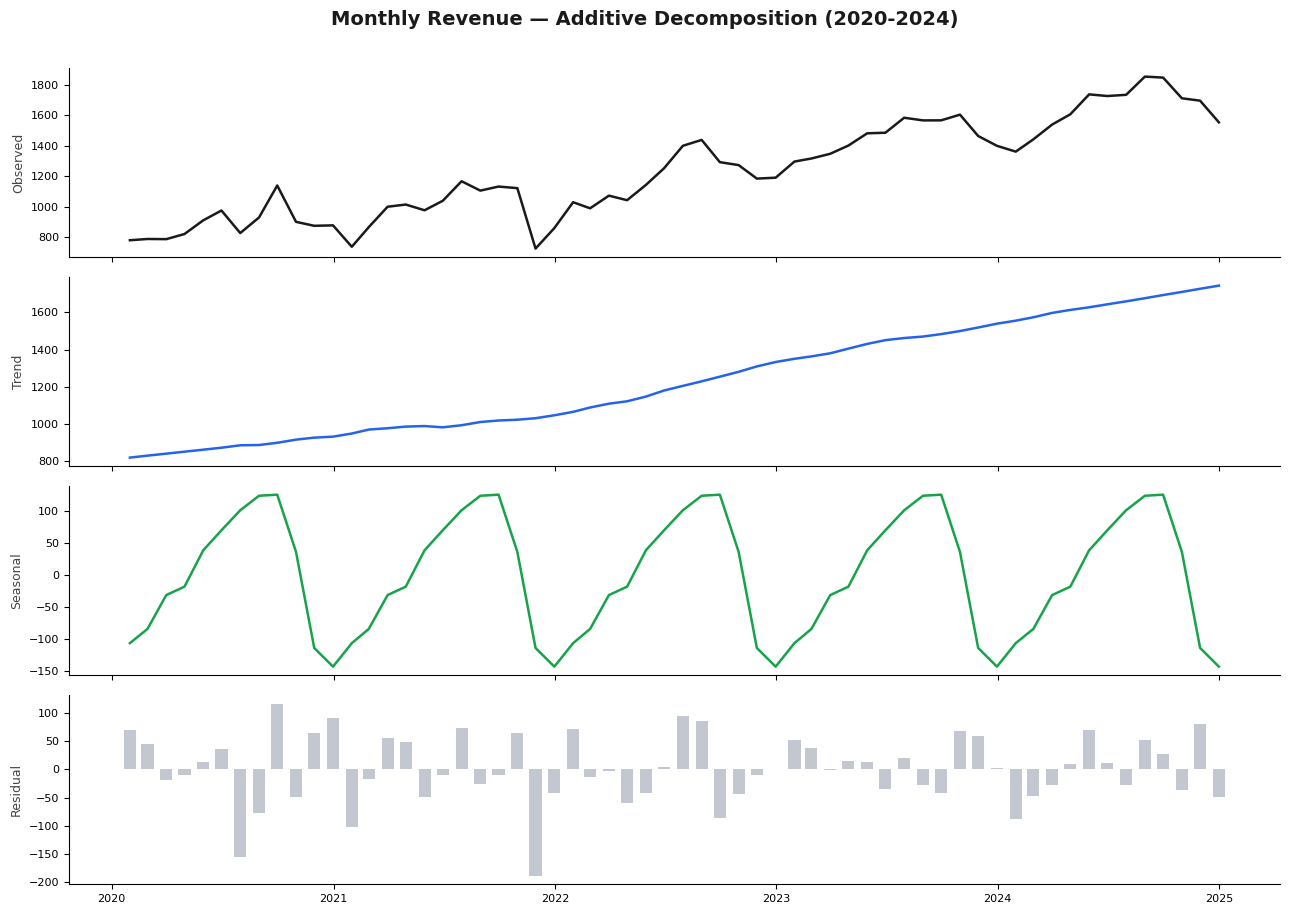

In [8]:
# Additive decomposition
fig = decomposition_chart(
    ts_series,
    period=12,
    model='additive',
    figsize=(13, 9),
    title='Monthly Revenue — Additive Decomposition (2020-2024)',
    trend_color='#2563EB',
    seasonal_color='#16A34A',
    residual_color='#9CA3AF',
    original_color='#1a1a1a',
)
plt.tight_layout()
plt.show()

## Time Series Decomposition — Visualization Notes

Biểu đồ tách time series thành **Observed, Trend, Seasonal, Residual** theo layout
stack dọc, giúp đọc từng thành phần độc lập.

### Small-multiples layout giảm chồng lấp
Các component được tách thành nhiều panel:

- tránh overlay nhiều đường
- dễ đọc từng thành phần
- giảm clutter

Giúp phân tích structure rõ ràng hơn.

### Trend panel làm nổi bật hướng dài hạn
Trend được tách riêng khỏi seasonal:

- loại bỏ dao động ngắn hạn
- dễ thấy long-term growth
- dễ phát hiện turning point

Không bị nhiễu bởi seasonality.

### Seasonal panel làm rõ pattern lặp lại
Seasonal được đặt riêng:

- thấy chu kỳ lặp lại
- thấy biên độ mùa vụ
- thấy timing peak / trough

Dễ xác định periodic behavior.

### Residual panel nhấn mạnh anomaly
Residual dùng bar quanh zero:

- highlight outliers
- thấy shock bất thường
- dễ so sánh magnitude deviation

Phù hợp anomaly detection.

### Căn trục thời gian giúp so sánh trực tiếp
Tất cả panel dùng chung trục x:

- so sánh cùng thời điểm
- thấy seasonal ảnh hưởng observed
- thấy residual khi trend bị lệch

Giữ alignment quan trọng.

### Phân tách signal vs noise rõ ràng
Decomposition giúp:

- Trend = signal dài hạn
- Seasonal = signal lặp lại
- Residual = noise / shock

Giúp hiểu cấu trúc time series nhanh.

## 7. Decomposition — Additive vs Multiplicative

Khi nào dùng additive vs multiplicative?

Visual test: nhìn vào seasonal component:

* Nếu biên độ seasonal không đổi khi trend tăng → Additive
* Nếu biên độ seasonal lớn hơn khi trend cao → Multiplicative

Dưới đây tạo 2 series để thấy rõ sự khác biệt.

---

### 7.1 Additive: seasonal amplitude cố định

Additive model:

Y = Trend + Seasonal + Residual

Đặc điểm:

* biên độ seasonal không đổi theo thời gian
* khoảng cách peak–trough ổn định
* variance không tăng theo level

Phù hợp khi seasonal là absolute change.

Ví dụ:

* retail tăng ±100 mỗi năm
* traffic tăng thêm lượng cố định
* demand có seasonality ổn định

---

### 7.2 Multiplicative: seasonal theo tỷ lệ

Multiplicative model:

Y = Trend × Seasonal × Residual

Đặc điểm:

* biên độ seasonal tăng theo trend
* peak cao hơn khi level cao hơn
* variance tăng theo level

Phù hợp khi seasonal là percentage change.

Ví dụ:

* doanh thu tăng ±10% mỗi năm
* traffic tăng theo tỷ lệ
* seasonal scale theo growth

---

### 7.3 Visual difference

Additive:

* band seasonal có độ cao giống nhau
* peak/trough ổn định theo thời gian
* residual variance ổn định

Multiplicative:

* band seasonal mở rộng theo thời gian
* peak ngày càng cao
* residual variance lớn hơn ở cuối series

---

### 7.4 Quy tắc chọn model

Chọn Additive khi:

* seasonal ổn định
* variance không đổi
* data linear growth

Chọn Multiplicative khi:

* seasonal scale theo level
* variance tăng theo trend
* data exponential growth

---

### 7.5 Log transform liên hệ multiplicative

Multiplicative có thể chuyển sang additive bằng log:

log(Y) = log(Trend) + log(Seasonal) + log(Residual)

Giúp:

* ổn định variance
* dễ decomposition
* phù hợp forecasting


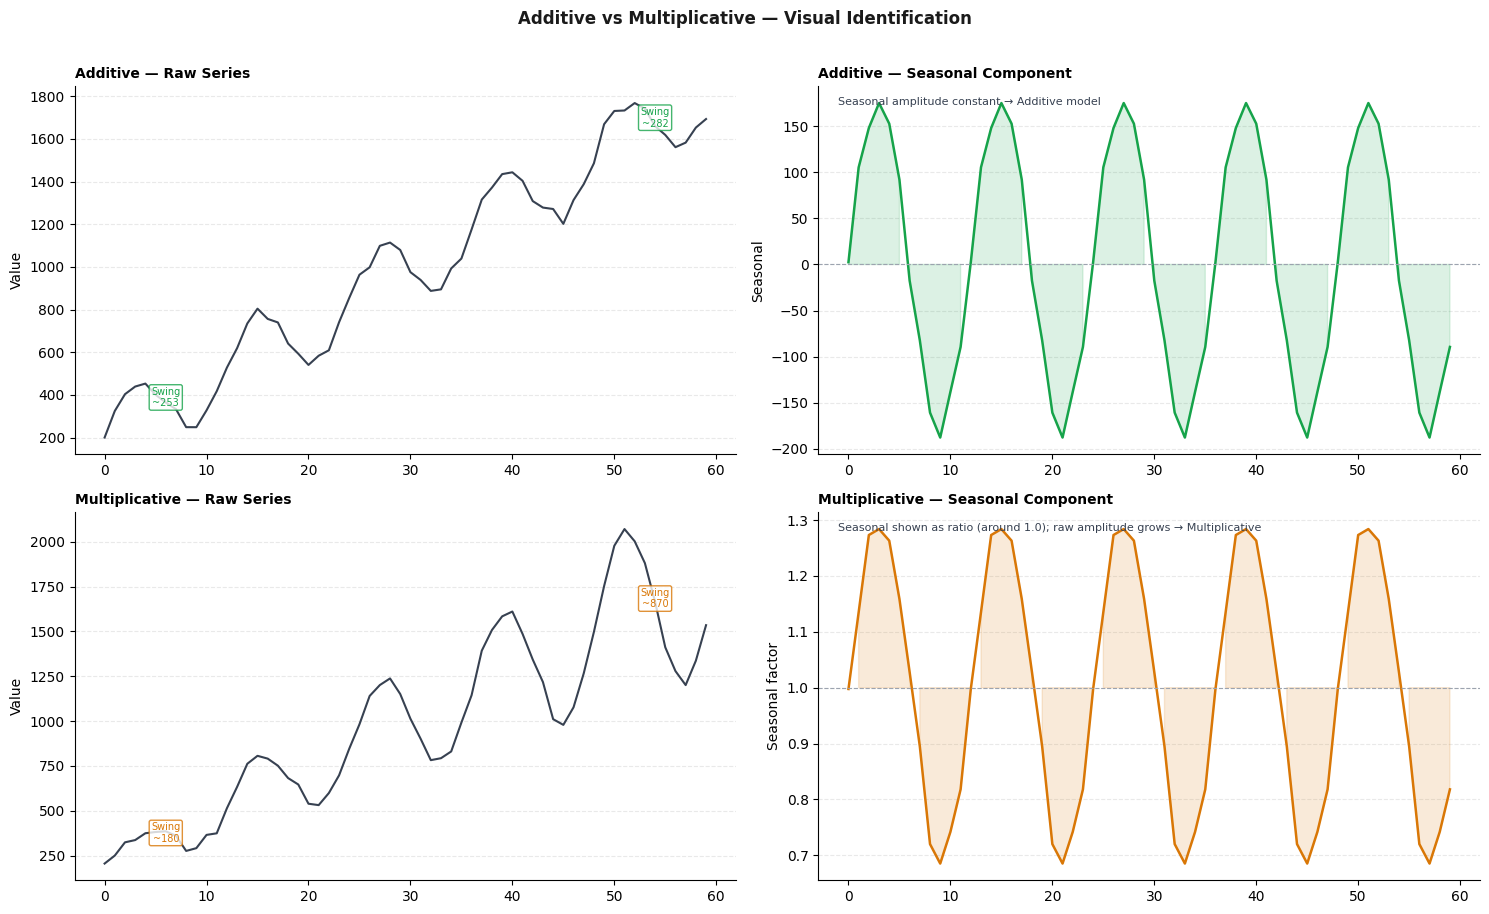

In [9]:
# Additive: seasonal amplitude CONSTANT regardless of trend level
# => biên độ mùa vụ đầu series = cuối series
t_arr     = np.arange(n_months)
trend_add = np.linspace(200, 1800, n_months)   # steep trend để contrast rõ
seasonal_const = 180 * np.sin(2 * np.pi * t_arr / 12)   # fixed ±180
rng = np.random.default_rng(7)
y_add = pd.Series(
    trend_add + seasonal_const + rng.normal(0, 25, n_months),
    index=idx,
)

# Multiplicative: seasonal amplitude GROWS with trend
# => biên độ mùa vụ cuối series lớn hơn nhiều so với đầu
seasonal_factor = 1 + 0.30 * np.sin(2 * np.pi * t_arr / 12)  # ±30% of trend
y_mul = pd.Series(
    trend_add * seasonal_factor + rng.normal(0, 25, n_months),
    index=idx,
)

from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(2, 2, figsize=(15, 9), facecolor='white')

for row, (y_ts, model, title_prefix, color) in enumerate([
    (y_add, 'additive',       'Additive',        '#16A34A'),
    (y_mul, 'multiplicative', 'Multiplicative',  '#D97706'),
]):
    result = seasonal_decompose(y_ts, model=model, period=12,
                                extrapolate_trend='freq')
    seasonal_vals = result.seasonal.values

    # ── Left: Raw series ──────────────────────────────────────────────────
    ax = axes[row][0]
    ax.plot(t_arr, y_ts.values, color='#374151', linewidth=1.5)

    # Annotate early vs late peak-to-trough swing
    early_swing = y_ts.values[:12].max() - y_ts.values[:12].min()
    late_swing  = y_ts.values[-12:].max() - y_ts.values[-12:].min()
    ax.annotate(f'Swing\n~{early_swing:.0f}',
                xy=(6, y_ts.values[:12].mean()),
                fontsize=7, color=color, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8))
    ax.annotate(f'Swing\n~{late_swing:.0f}',
                xy=(54, y_ts.values[-12:].mean()),
                fontsize=7, color=color, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8))

    ax.set_title(f'{title_prefix} — Raw Series',
                 loc='left', fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')
    despine(ax); set_grid(ax)

    # ── Right: Seasonal component ─────────────────────────────────────────
    ax = axes[row][1]
    baseline = 0 if model == 'additive' else 1
    ax.plot(t_arr, seasonal_vals, color=color, linewidth=1.8)
    ax.axhline(baseline, color='#9CA3AF', linewidth=0.8, linestyle='--')
    ax.fill_between(t_arr, seasonal_vals, baseline,
                    where=(seasonal_vals > baseline), color=color, alpha=0.15)
    ax.fill_between(t_arr, seasonal_vals, baseline,
                    where=(seasonal_vals < baseline), color=color, alpha=0.15)

    ax.set_title(f'{title_prefix} — Seasonal Component',
                 loc='left', fontsize=10, fontweight='bold')
    ax.set_ylabel('Seasonal' if model == 'additive' else 'Seasonal factor')

    insight = (
        'Seasonal amplitude constant → Additive model'
        if model == 'additive'
        else 'Seasonal shown as ratio (around 1.0); raw amplitude grows → Multiplicative'
    )
    add_note(ax, insight, x=0.03, y=0.97, color='#374151', fontsize=8)
    despine(ax); set_grid(ax)

fig.suptitle('Additive vs Multiplicative — Visual Identification',
             fontsize=12, fontweight='bold', color='#1a1a1a', y=1.01)
plt.tight_layout()
plt.show()

## Additive vs Multiplicative — Visualization Notes

Biểu đồ đặt **additive** và **multiplicative** cạnh nhau để nhận diện
khác biệt về seasonal amplitude theo trend.

### Raw series cho thấy amplitude behavior
Panel bên trái hiển thị raw time series:

- Additive: biên độ đầu và cuối gần như giống nhau
- Multiplicative: biên độ tăng mạnh khi trend cao hơn

So sánh early vs late swing giúp nhận diện nhanh model.

### Seasonal component xác nhận mô hình
Panel bên phải hiển thị seasonal đã tách:

- Additive: dao động quanh 0 với amplitude cố định
- Multiplicative: dao động quanh 1.0 như một factor

Giúp phân biệt additive vs multiplicative trực tiếp.

### Baseline khác nhau làm rõ interpretation
Hai seasonal dùng baseline khác:

- Additive centered tại 0
- Multiplicative centered tại 1

Thể hiện:

- additive = absolute deviation
- multiplicative = percentage factor

### Small-multiples layout giúp so sánh trực tiếp
Additive và multiplicative đặt cùng layout:

- cùng trục thời gian
- cùng cấu trúc panel
- dễ so sánh trực quan

Giảm cognitive load khi đọc.

### Raw + Seasonal kết hợp để nhận diện
Raw series cho thấy:

- amplitude tăng hay không

Seasonal panel cho thấy:

- seasonal dạng additive hay ratio

Hai panel bổ sung để xác định model.

### Visual rule rút ra
Additive:

- seasonal amplitude không đổi
- variance ổn định
- deviation tuyệt đối

Multiplicative:

- raw amplitude tăng theo trend
- seasonal là tỷ lệ quanh 1
- deviation theo phần trăm

## 8. Reading Residuals — Anomaly Detection

Residual = phần còn lại sau khi loại bỏ trend và seasonality.
Phần này đại diện cho **noise + shocks + anomalies**.

Residual lớn bất thường (|residual| >> σ) cho thấy có sự kiện khác thường
không được giải thích bởi trend hoặc seasonal.

---

### 8.1 Residual tách signal khỏi anomaly

Sau decomposition:

- Trend → hướng dài hạn
- Seasonal → pattern lặp lại
- Residual → deviation bất thường

Residual trở thành nơi tập trung anomaly.

---

### 8.2 Nhận diện outlier bằng độ lệch lớn

Residual có magnitude lớn cho thấy:

- spike bất thường
- drop bất thường
- deviation không theo pattern

Các điểm này dễ thấy khi residual vượt xa vùng xung quanh.

---

### 8.3 Phân biệt các loại anomaly

Residual lớn có thể do:

- data quality issue
- shock bên ngoài
- structural break
- event đặc biệt

Decomposition giúp loại bỏ seasonal để tránh false alarm.

---

### 8.4 Residual centered quanh zero

Residual dao động quanh baseline:

- additive → quanh 0
- multiplicative → quanh 1 (sau transform)

Deviation khỏi baseline dễ nhận biết visually.

---

### 8.5 Residual tốt cho anomaly detection

Residual giúp:

- phát hiện outliers
- phát hiện regime shift
- phát hiện data errors
- phát hiện event impact

Phù hợp monitoring time series.

---

### 8.6 Quy tắc thực hành

Anomaly thường khi:

- |residual| > 2σ → suspicious
- |residual| > 3σ → strong anomaly
- residual cluster → regime change

Giúp định nghĩa alert threshold.

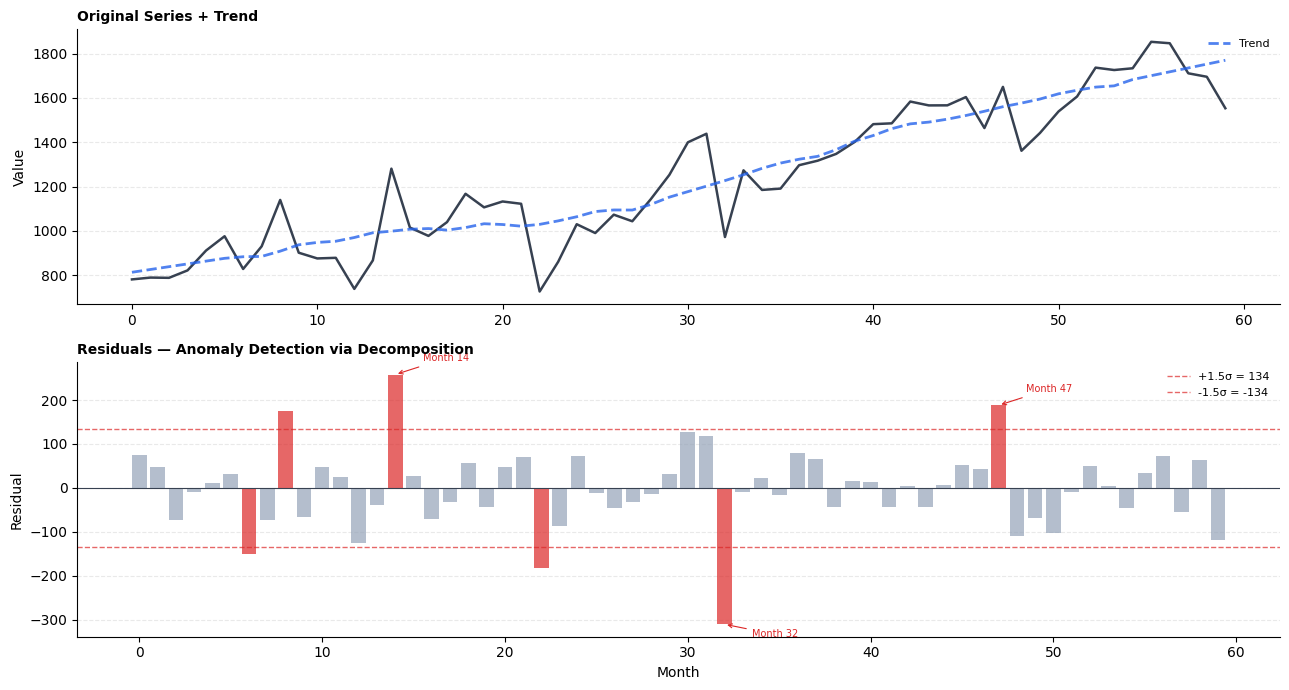

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from vizint.perception.outlier import detect_and_mark_outliers, emphasize_outliers

# Inject anomalies into ts_series
ts_with_anomaly = ts_series.copy()
anomaly_months = [14, 32, 47]   # inject shocks
ts_with_anomaly.iloc[anomaly_months] += np.array([280, -320, 250])

# Decompose
result = seasonal_decompose(ts_with_anomaly, model='additive',
                            period=12, extrapolate_trend='freq')
residuals = result.resid.values
t_arr_plot = np.arange(len(residuals))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), facecolor='white')

# Panel 1: Original series with anomalies
ax = axes[0]
ax.plot(t_arr_plot, ts_with_anomaly.values,
        color='#374151', linewidth=1.8)
ax.plot(t_arr_plot, result.trend.values,
        color='#2563EB', linewidth=2.0, linestyle='--',
        label='Trend', alpha=0.8)
ax.set_title('Original Series + Trend',
             loc='left', fontsize=10, fontweight='bold')
ax.legend(frameon=False, fontsize=8)
ax.set_ylabel('Value')
despine(ax); set_grid(ax)

# Panel 2: Residuals with outlier detection
ax = axes[1]
ax.bar(t_arr_plot, residuals,
       color=['#DC2626' if abs(r) > 1.5 * np.nanstd(residuals) else '#94A3B8'
              for r in residuals],
       width=0.8, alpha=0.7)
ax.axhline(0, color='#374151', linewidth=0.8)

# Threshold lines (±1.5σ)
sig = np.nanstd(residuals)
ax.axhline(+1.5 * sig, color='#DC2626', linewidth=1.0,
           linestyle='--', alpha=0.7, label=f'+1.5σ = {1.5*sig:.0f}')
ax.axhline(-1.5 * sig, color='#DC2626', linewidth=1.0,
           linestyle='--', alpha=0.7, label=f'-1.5σ = {-1.5*sig:.0f}')

# Annotate the 3 injected anomalies
for m in anomaly_months:
    ax.annotate(f'Month {m}',
                xy=(m, residuals[m]),
                xytext=(m + 1.5, residuals[m] + 30 * np.sign(residuals[m])),
                fontsize=7, color='#DC2626',
                arrowprops=dict(arrowstyle='->', color='#DC2626', lw=0.8))

ax.legend(frameon=False, fontsize=8)
ax.set_title('Residuals — Anomaly Detection via Decomposition',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Residual')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

## Residuals — Visualization Notes

Biểu đồ kết hợp **original + trend** với **residual bars** để làm nổi bật
các điểm bất thường sau khi loại bỏ trend.

### Residual panel tách anomaly khỏi trend
Panel trên cho thấy:

- biến động quanh trend
- deviation khó phân biệt

Panel dưới hiển thị residual:

- chỉ còn phần bất thường
- anomaly nổi bật rõ ràng

Giúp tách signal khỏi noise.

### Threshold lines tạo rule trực quan
Các đường ±1.5σ đóng vai trò:

- vùng bình thường
- ngưỡng cảnh báo
- highlight anomaly

Residual vượt ngưỡng được tô màu nổi bật.

### Bar chart phù hợp cho residual
Residual dùng bar thay vì line:

- dễ so sánh magnitude
- dễ thấy spike
- dễ nhận diện outlier

Phù hợp anomaly detection.

### Centered around zero giúp đọc deviation
Residual dao động quanh baseline 0:

- trên 0 → cao hơn expected
- dưới 0 → thấp hơn expected
- xa 0 → anomaly mạnh

Giúp đọc deviation trực tiếp.

### Highlight anomalies giảm nhiễu
Chỉ các điểm vượt threshold được tô đỏ:

- focus vào anomaly
- phần còn lại muted
- giảm clutter

Giúp attention đúng chỗ.

### Layout trên–dưới giúp liên hệ nguyên nhân
Chart trên:

- thấy vị trí spike

Chart dưới:

- thấy magnitude anomaly

Hai panel liên kết theo trục thời gian giúp xác định
thời điểm bất thường chính xác.

## 9. Full Process Dashboard

Kết hợp waterfall + contribution + stacked area trong layout 2×2
tạo dashboard hoàn chỉnh cho một P&L review.

Dashboard thường gồm:

- Waterfall — variance / P&L bridge
- Contribution chart — share of total
- Stacked area — mix theo thời gian
- 100% stacked — share dynamics

---

### 9.1 Multi-chart layout cho narrative hoàn chỉnh

Mỗi chart trả lời một câu hỏi khác nhau:

- Waterfall → vì sao thay đổi
- Contribution → ai chiếm nhiều nhất
- Stacked area → tổng tăng ra sao
- 100% stacked → mix thay đổi thế nào

Đặt cùng layout giúp đọc theo storytelling.

---

### 9.2 Tách magnitude vs composition

Dashboard phân biệt rõ:

- magnitude change (waterfall, stacked absolute)
- composition change (contribution, 100% stacked)

Tránh hiểu sai khi chỉ nhìn một loại chart.

---

### 9.3 Cross-panel consistency

Các chart dùng:

- cùng category colors
- cùng segment order
- cùng time axis (khi có)

Giúp người xem map thông tin giữa panels.

---

### 9.4 Top-left → bottom-right reading flow

Layout 2×2 tạo flow tự nhiên:

- top-left: tổng quan thay đổi
- top-right: cấu trúc hiện tại
- bottom-left: evolution theo thời gian
- bottom-right: share dynamics

Hỗ trợ narrative logic.

---

### 9.5 Complementary visual roles

Waterfall:

- highlight drivers
- show variance

Contribution:

- ranking segments
- share hiện tại

Stacked area:

- growth theo thời gian
- segment expansion

100% stacked:

- mix shift
- dominance change

---

### 9.6 Phù hợp dashboard P&L review

Layout này phù hợp:

- monthly business review
- revenue mix analysis
- segment performance
- executive dashboard

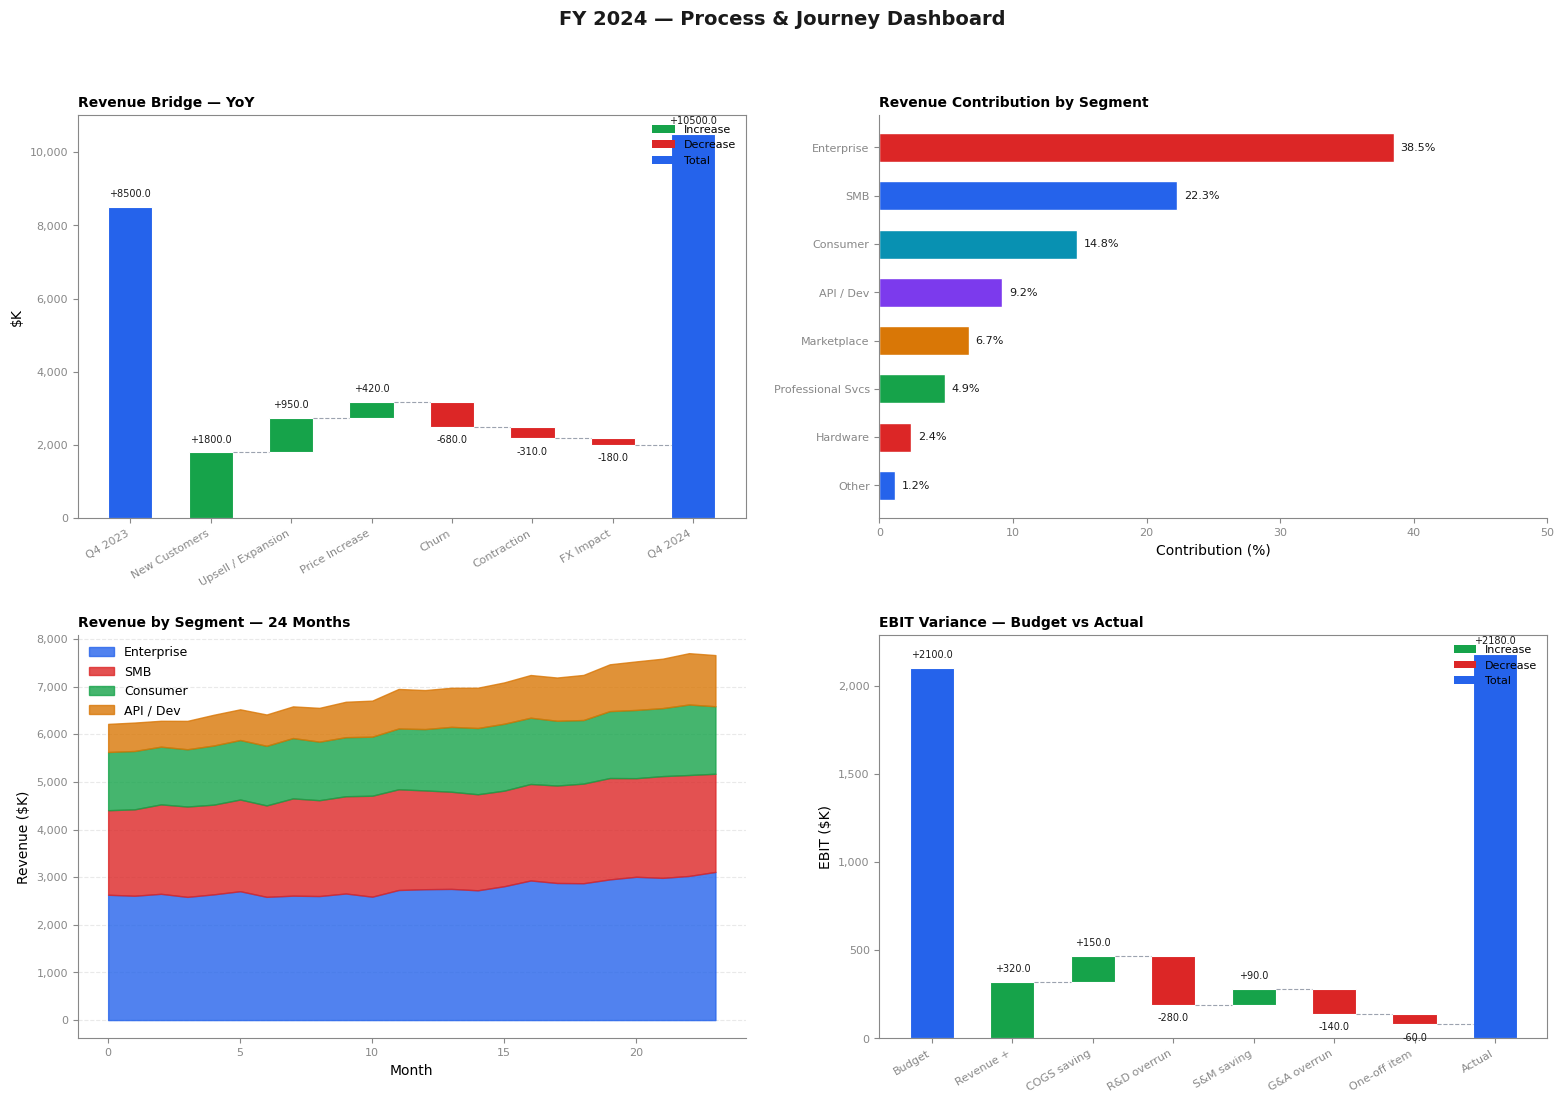

In [11]:
fig = plt.figure(figsize=(16, 11), facecolor='white')
fig.suptitle('FY 2024 — Process & Journey Dashboard',
             fontsize=14, fontweight='bold', color='#1a1a1a', y=1.01)

# Layout: 2 rows, 2 cols
ax1 = fig.add_subplot(2, 2, 1)   # Revenue bridge
ax2 = fig.add_subplot(2, 2, 2)   # P&L contribution
ax3 = fig.add_subplot(2, 2, 3)   # Stacked revenue over time
ax4 = fig.add_subplot(2, 2, 4)   # Budget variance

# ── Panel 1: Revenue Bridge ───────────────────────────────────────────────
waterfall_chart(
    ax1,
    labels=revenue_bridge_labels,
    values=revenue_bridge_values,
    positive_color='#16A34A', negative_color='#DC2626', total_color='#2563EB',
    total_indices=[0, 7], bar_width=0.55, show_values=True, value_fontsize=7,
)
ax1.set_title('Revenue Bridge — YoY', loc='left', fontsize=10, fontweight='bold')
format_thousands(ax1, 'y'); ax1.set_ylabel('$K')
set_tick_style(ax1, labelsize=8)

# ── Panel 2: Contribution ────────────────────────────────────────────────
contribution_chart(
    ax2,
    categories=products_contrib,
    contributions=contrib_values,
    palette='default',
    bar_height=0.60,
    show_values=True,
    value_fmt='{:.1f}%',
    sort=True,
)
ax2.set_title('Revenue Contribution by Segment', loc='left', fontsize=10, fontweight='bold')
ax2.set_xlim(0, 50)
set_tick_style(ax2, labelsize=8)
despine(ax2, left=False)

# ── Panel 3: Stacked area ────────────────────────────────────────────────
stacked_contribution(
    ax3,
    x=months_t,
    series=segment_series,
    palette='default',
    alpha=0.80,
    legend=True,
    legend_loc='upper left',
)
ax3.set_title('Revenue by Segment — 24 Months', loc='left', fontsize=10, fontweight='bold')
ax3.set_xlabel('Month'); ax3.set_ylabel('Revenue ($K)')
format_thousands(ax3, 'y')
despine(ax3); set_grid(ax3)
set_tick_style(ax3, labelsize=8)

# ── Panel 4: Budget Variance ─────────────────────────────────────────────
waterfall_chart(
    ax4,
    labels=variance_labels,
    values=variance_values,
    positive_color='#16A34A', negative_color='#DC2626', total_color='#2563EB',
    total_indices=[0, 7], bar_width=0.55, show_values=True, value_fontsize=7,
)
ax4.set_title('EBIT Variance — Budget vs Actual', loc='left', fontsize=10, fontweight='bold')
format_thousands(ax4, 'y'); ax4.set_ylabel('EBIT ($K)')
set_tick_style(ax4, labelsize=8)

plt.tight_layout(pad=2.0)
plt.show()

## Full Process Dashboard — Visualization Notes

Dashboard 2×2 kết hợp waterfall, contribution và stacked area
để trình bày toàn bộ P&L journey trong một view duy nhất.

### Multi-panel layout hỗ trợ storytelling
Bốn panel trả lời các câu hỏi khác nhau:

- Revenue bridge → điều gì thay đổi YoY
- Contribution → segment nào chiếm nhiều nhất
- Stacked area → revenue tăng theo thời gian
- EBIT waterfall → impact lên profitability

Tạo narrative từ growth → mix → profit.

### Top-left bắt đầu bằng drivers
Revenue waterfall đặt ở góc trên trái:

- highlight growth drivers
- tách increase vs decrease
- bridge từ start → end

Đóng vai trò entry point của dashboard.

### Top-right hiển thị composition hiện tại
Contribution chart cho thấy:

- segment ranking
- share of total
- dominance của top segment

Giúp hiểu cấu trúc revenue ngay lập tức.

### Bottom-left thể hiện evolution theo thời gian
Stacked area hiển thị:

- total growth
- segment expansion
- mix thay đổi

Bổ sung chiều thời gian cho contribution.

### Bottom-right kết thúc bằng profitability impact
EBIT waterfall cho thấy:

- variance vs budget
- cost drivers
- net profit impact

Kết thúc narrative bằng bottom line.

### Cross-panel consistency giúp đọc nhanh
Các panel dùng:

- cùng segment colors
- cùng order segment
- cùng logic favorable/unfavorable

Giúp liên kết thông tin giữa charts.

### End-to-end business flow
Dashboard thể hiện:

Drivers → Mix → Growth → Profit

Một layout duy nhất cho P&L review.

---
## Summary

| Technique | Function | Câu hỏi trả lời |
|-----------|----------|------------------|
| Waterfall — bridge | `waterfall_chart` | Từ A đến B qua những bước nào? |
| Waterfall — P&L | `waterfall_chart` (subtotals) | Revenue → Net Income |
| Waterfall — variance | `waterfall_chart` | Budget vs Actual từng dòng |
| Contribution bar | `contribution_chart` | Mỗi category = bao nhiêu % tổng? |
| Stacked area | `stacked_contribution` | Contribution thay đổi theo thời gian |
| 100% stacked | Normalize + `stacked_contribution` | Tỷ trọng thay đổi như thế nào? |
| Decomposition | `decomposition_chart` | Trend + Seasonal + Residual |
| Residual analysis | Manual (bar + thresholds) | Anomaly detection sau decompose |

---

### Key Takeaway

> Snapshot nói với bạn **bạn đang ở đâu**.
> Journey nói với bạn **làm thế nào bạn đến đây và điều gì đang thúc đẩy bạn**.
>
> Waterfall giải thích **change**. Contribution giải thích **composition**. Decomposition giải thích **structure**.
> Ba kỹ thuật này cùng nhau cho thấy toàn bộ câu chuyện đằng sau một con số.

**Next →** `07_framing_and_bias.ipynb` — Cùng một data, nhiều câu chuyện khác nhau: cách framing tạo ra bias và cách nhận diện / tránh nó.